In [1]:
!pwd

/content


In [2]:
!git clone

Cloning into 'robust-eeg-models'...
remote: Enumerating objects: 321, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 321 (delta 59), reused 52 (delta 50), pack-reused 258 (from 1)
Receiving objects: 100% (321/321), 215.73 MiB | 15.69 MiB/s, done.
Resolving deltas: 100% (182/182), done.
Updating files: 100% (119/119), done.


In [2]:
%cd /content/robust-eeg-models

/content/robust-eeg-models


In [4]:
import pandas as pd
deepconvnet_df = pd.read_csv('DeepConvNet_final_all_trials.csv')
deepconvnet_df.head()

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout,params_lr,params_weight_decay,state
0,0,0.572806,2025-07-10 15:36:32.152678,2025-07-10 15:39:29.458838,0 days 00:02:57.306160,64,0.211978,0.005738,0.000001,COMPLETE
1,1,0.495661,2025-07-10 15:39:29.486218,2025-07-10 15:42:31.961399,0 days 00:03:02.475181,32,0.452170,0.000107,0.002148,COMPLETE
2,2,0.571842,2025-07-10 15:42:31.986166,2025-07-10 15:44:51.887387,0 days 00:02:19.901221,32,0.113327,0.000945,0.000127,COMPLETE
3,3,0.513983,2025-07-10 15:44:51.912953,2025-07-10 15:47:59.785964,0 days 00:03:07.873011,16,0.462356,0.000051,0.000003,COMPLETE
4,4,0.473481,2025-07-10 15:47:59.809877,2025-07-10 15:49:59.591979,0 days 00:01:59.782102,16,0.432224,0.001069,0.004349,COMPLETE


In [5]:
deepconvnet_params = deepconvnet_df[deepconvnet_df['value']==deepconvnet_df['value'].max()]
deepconvnet_params

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout,params_lr,params_weight_decay,state
57,57,0.593057,2025-07-10 16:11:29.409048,2025-07-10 16:14:31.543463,0 days 00:03:02.134415,16,0.160096,0.000913,0.000004,COMPLETE


In [6]:
eegnet_df = pd.read_csv('EEGNet_final_all_trials.csv')
eegnet_df.head()

,number,value,datetime_start,datetime_complete,duration,params_D,params_F1,params_batch_size,params_dropout,params_lr,params_weight_decay,state
0,0,0.558341,2025-07-09 15:14:58.109114,2025-07-09 15:17:18.585423,0 days 00:02:20.476309,2,16,64,0.245054,0.002432,0.000628,COMPLETE
1,1,NaN,2025-07-09 15:17:18.612048,2025-07-09 15:29:59.469615,0 days 00:12:40.857567,8,32,16,0.399436,0.000040,0.000249,FAIL
2,2,0.632594,2025-07-09 15:30:07.370268,2025-07-09 15:40:48.108049,0 days 00:10:40.737781,2,32,16,0.129887,0.000870,0.002451,COMPLETE
3,3,0.593057,2025-07-09 15:40:48.135532,2025-07-09 15:51:15.830753,0 days 00:10:27.695221,2,32,32,0.106628,0.002513,0.000006,COMPLETE
4,4,0.612343,2025-07-09 15:51:15.855600,2025-07-09 16:03:01.906768,0 days 00:11:46.051168,4,32,32,0.256835,0.000925,0.000329,COMPLETE


In [7]:

eegnet_params = eegnet_df[eegnet_df['value']==eegnet_df['value'].max()]
eegnet_params

,number,value,datetime_start,datetime_complete,duration,params_D,params_F1,params_batch_size,params_dropout,params_lr,params_weight_decay,state
2,2,0.632594,2025-07-09 15:30:07.370268,2025-07-09 15:40:48.108049,0 days 00:10:40.737781,2,32,16,0.129887,0.00087,0.002451,COMPLETE


In [3]:
!git config --global user.email "chianumbav@gmial.com"
!git config --global user.name "Victory Chianumba"


In [4]:
!git remote set-url origin


In [ ]:
!git pull origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [5]:
!pip install torch torchvision torchaudio
!pip install mne moabb
!pip install torch-lr-finder
!pip install optuna


In [6]:
import torch
import importlib
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

import numpy as np
import os
import sys

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

from models.eegnet import EEGNet
from models.deepconvnet import DeepConvNet
from models.CNN import CNN
from models.EEGTransformer import EEGTransformer
from models.MultiscaleEEG import MultiScaleEEGTransformer
from models.EEG_VIT import EEGViT

from utils.eeg_augmentations import EEGAugmentation

from training.run_optimization import run_optimization




In [8]:
import optuna

def load_best_params_from_db(model_type='EEGNet'):
    """Load best parameters from Optuna database"""

    # Load the study from database
    study = optuna.load_study(
        study_name=f'{model_type}_optimization',
        storage=f'sqlite:///{model_type}_study.db'
    )

    print(f"📊 {model_type} Study Summary:")
    print(f"   Number of trials: {len(study.trials)}")
    print(f"   Best value: {study.best_value:.6f}")
    print(f"   Best trial number: {study.best_trial.number}")

    return study.best_params, study.best_value, study

# Load your results
eegnet_params, eegnet_score, eegnet_study = load_best_params_from_db('EEGNet')
deepconv_params, deepconv_score, deepconv_study = load_best_params_from_db('DeepConvNet')

print("🏆 EEGNet Best Parameters:")
for param, value in eegnet_params.items():
    print(f"   {param}: {value}")

print("\n🏆 DeepConvNet Best Parameters:")
for param, value in deepconv_params.items():
    print(f"   {param}: {value}")

📊 EEGNet Study Summary:
   Number of trials: 62
   Best value: 0.632594
   Best trial number: 2
📊 DeepConvNet Study Summary:
   Number of trials: 60
   Best value: 0.593057
   Best trial number: 57
🏆 EEGNet Best Parameters:
   batch_size: 16
   lr: 0.0008704749593073274
   weight_decay: 0.002451031998106575
   dropout: 0.12988679302154116
   F1: 32
   D: 2

🏆 DeepConvNet Best Parameters:
   batch_size: 16
   lr: 0.0009125453828332987
   weight_decay: 3.5161560154775886e-06
   dropout: 0.1600960468442516


In [35]:
import optuna

def create_optimized_models_from_db():
    """Create optimized models directly from database parameters"""

    # Load studies
    eegnet_study = optuna.load_study(
        study_name='EEGNet_optimization',
        storage='sqlite:///EEGNet_study.db'
    )

    deepconv_study = optuna.load_study(
        study_name='DeepConvNet_optimization',
        storage='sqlite:///DeepConvNet_study.db'
    )

    # Extract best parameters
    eegnet_params = eegnet_study.best_params
    deepconv_params = deepconv_study.best_params

    # Create optimized models
    optimized_eegnet = EEGNet(
        num_classes=4,
        channels=22,
        samples=1001,
        F1=eegnet_params['F1'],
        D=eegnet_params['D'],
        dropout=eegnet_params['dropout']
    )

    optimized_deepconvnet = DeepConvNet(
        num_classes=4,
        channels=22,
        samples=1125,  # Adjust based on your data
        dropout=deepconv_params['dropout']
    )

    # Return models and training parameters
    training_params = {
        'eegnet': {
            'lr': eegnet_params['lr'],
            'weight_decay': eegnet_params['weight_decay'],
            'batch_size': eegnet_params['batch_size']
        },
        'deepconv': {
            'lr': deepconv_params['lr'],
            'weight_decay': deepconv_params['weight_decay'],
            'batch_size': deepconv_params['batch_size']
        }
    }

    return optimized_eegnet, optimized_deepconvnet, training_params

# Create your optimized models
eegnet_model, deepconv_model, train_params = create_optimized_models_from_db()

In [17]:
eegnet_model

(EEGNet(
   (firstconv): Sequential(
     (0): Conv2d(1, 32, kernel_size=(1, 51), stride=(1, 1), padding=(0, 25), bias=False)
     (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (depthwiseConv): Sequential(
     (0): Conv2d(32, 64, kernel_size=(22, 1), stride=(1, 1), groups=32, bias=False)
     (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ELU(alpha=1.0)
     (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
     (4): Dropout(p=0.12988679302154116, inplace=False)
   )
   (separableConv): Sequential(
     (0): Conv2d(64, 64, kernel_size=(1, 15), stride=(1, 1), padding=(0, 7), bias=False)
     (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ELU(alpha=1.0)
     (3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
     (4): Dropout(p=0.12988679302154116, inplace=False)
   )
   (classify): Linear(in_features=2240, out_features=4, bi

In [13]:
def analyze_optimization_results(study):
    """Analyze the full optimization results"""

    # Convert to DataFrame for analysis
    trials_df = study.trials_dataframe()

    # Basic statistics
    print(f"📈 Optimization Analysis:")
    print(f"   Total trials: {len(trials_df)}")
    print(f"   Completed trials: {len(trials_df[trials_df['state'] == 'COMPLETE'])}")
    print(f"   Best value: {study.best_value:.6f}")
    print(f"   Worst value: {trials_df['value'].min():.6f}")
    print(f"   Mean value: {trials_df['value'].mean():.6f}")
    print(f"   Std value: {trials_df['value'].std():.6f}")

    # Parameter importance
    print(f"\n🎯 Parameter Importance:")
    try:
        param_importance = optuna.importance.get_param_importances(study)
        for param, importance in param_importance.items():
            print(f"   {param}: {importance:.4f}")
    except:
        print("   Could not calculate parameter importance")

    # Top 5 trials
    print(f"\n🏆 Top 5 Trials:")
    top_trials = trials_df.nlargest(5, 'value')
    for idx, trial in top_trials.iterrows():
        print(f"   Trial {trial['number']}: {trial['value']:.6f}")

    return trials_df

# Analyze your studies
eegnet_analysis = analyze_optimization_results(eegnet_study)
deepconv_analysis = analyze_optimization_results(deepconv_study)

📈 Optimization Analysis:
   Total trials: 62
   Completed trials: 6
   Best value: 0.632594
   Worst value: 0.272903
   Mean value: 0.419337
   Std value: 0.082785

🎯 Parameter Importance:
   batch_size: 0.2612
   lr: 0.2583
   dropout: 0.2395
   F1: 0.1319
   D: 0.0751
   weight_decay: 0.0339

🏆 Top 5 Trials:
   Trial 2: 0.632594
   Trial 4: 0.612343
   Trial 53: 0.599807
   Trial 3: 0.593057
   Trial 0: 0.558341
📈 Optimization Analysis:
   Total trials: 60
   Completed trials: 12
   Best value: 0.593057
   Worst value: 0.257473
   Mean value: 0.376680
   Std value: 0.105016

🎯 Parameter Importance:
   dropout: 0.6603
   lr: 0.1911
   weight_decay: 0.1384
   batch_size: 0.0101

🏆 Top 5 Trials:
   Trial 57: 0.593057
   Trial 43: 0.582449
   Trial 0: 0.572806
   Trial 2: 0.571842
   Trial 11: 0.564127


In [18]:
# ---------- Config ----------
subject_id = 8
batch_size = 32
epochs = 200
lr = 0.0001
lr = {
    "EEGNet": 0.0001,
    "DeepConvNet": 0.00025,
    "CNN": 0.0001,
    "EEGTransformer": 0.0001,
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [19]:
# Replace your entire preprocessing with:
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

ds = BNCI2014_001()
paradigm = MotorImagery(n_classes=4)
X, labels, meta = paradigm.get_data(dataset=ds, subjects=[1, 2, 3, 4, 5, 6, 7, 8, 9])  # Single subject first

/usr/local/lib/python3.11/dist-packages/moabb/datasets/download.py:56: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))


MNE_DATA is not already configured. It will be set to default location in the home directory - /root/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location


/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 50.7GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
100%|█████████████████████████████████████| 43.8M/43.8M [

In [20]:
print(f"Raw data shape: {X.shape}")
print(f"Labels: {np.unique(labels)}")

# 2. CONVERT LABELS TO NUMERIC (like supervisor)
class_map = {'left_hand': 0, 'right_hand': 1, 'feet': 2, 'tongue': 3}
y_numeric = np.array([class_map[label] for label in labels])

# 3. APPLY YOUR LABEL CLEANING LOGIC
y = y_numeric.copy()

# Filter out any invalid samples (e.g., negative class labels)
valid_mask = y >= 0
X = X[valid_mask]
y = y[valid_mask]

# Debug: Check what labels look like
print("Original labels:", np.unique(y), "min:", y.min(), "max:", y.max())

# Remap labels to start from 0 (though they should already be 0-3)
unique_labels = np.unique(y)
label_map = {old: new for new, old in enumerate(unique_labels)}
y = np.vectorize(label_map.get)(y)

print("Cleaned labels:", np.unique(y), "min:", y.min(), "max:", y.max())

# 4. PREPARE FOR PYTORCH (like supervisor)
X = torch.tensor(X, dtype=torch.float32)  # Add channel dimension
y = torch.tensor(y, dtype=torch.long)

X=X.unsqueeze(axis=1)

print(f"Final tensor shapes: X={X.shape}, y={y.shape}")
print(f"Shapes of the objects: X={X.dtype}, y={y.dtype}")


Raw data shape: (5184, 22, 1001)
Labels: ['feet' 'left_hand' 'right_hand' 'tongue']
Original labels: [0 1 2 3] min: 0 max: 3
Cleaned labels: [0 1 2 3] min: 0 max: 3
Final tensor shapes: X=torch.Size([5184, 1, 22, 1001]), y=torch.Size([5184])
Shapes of the objects: X=torch.float32, y=torch.int64


In [21]:
X /= X.std()

In [134]:
eegnet_study = run_optimization(X, y, model_type='EEGNet', n_trials=50)

[I 2025-07-09 15:30:07,348] Using an existing study with name 'EEGNet_optimization' instead of creating a new one.
[I 2025-07-09 15:40:48,127] Trial 2 finished with value: 0.6325940212150434 and parameters: {'batch_size': 16, 'lr': 0.0008704749593073274, 'weight_decay': 0.002451031998106575, 'dropout': 0.12988679302154116, 'F1': 32, 'D': 2}. Best is trial 2 with value: 0.6325940212150434.
[I 2025-07-09 15:51:15,847] Trial 3 finished with value: 0.5930568948891032 and parameters: {'batch_size': 32, 'lr': 0.0025132114428899413, 'weight_decay': 6.038508779710614e-06, 'dropout': 0.10662803837973223, 'F1': 32, 'D': 2}. Best is trial 2 with value: 0.6325940212150434.
[I 2025-07-09 16:03:01,923] Trial 4 finished with value: 0.6123432979749277 and parameters: {'batch_size': 32, 'lr': 0.0009246843694618241, 'weight_decay': 0.00032921643700803166, 'dropout': 0.2568350735761513, 'F1': 32, 'D': 4}. Best is trial 2 with value: 0.6325940212150434.
[I 2025-07-09 16:13:43,011] Trial 5 finished with va

✅ Study saved as:
  - EEGNet_trial_35_study.pkl (full study)
  - EEGNet_trial_35_best_results.json (best config)
  - EEGNet_trial_35_all_trials.csv (all trials)
💾 Progress saved at trial 35


[I 2025-07-09 16:22:46,304] Trial 36 pruned. 
[I 2025-07-09 16:22:51,328] Trial 37 pruned. 
[I 2025-07-09 16:23:07,064] Trial 38 pruned. 
[I 2025-07-09 16:23:22,484] Trial 39 pruned. 
[I 2025-07-09 16:23:25,569] Trial 40 pruned. 


✅ Study saved as:
  - EEGNet_trial_40_study.pkl (full study)
  - EEGNet_trial_40_best_results.json (best config)
  - EEGNet_trial_40_all_trials.csv (all trials)
💾 Progress saved at trial 40


[I 2025-07-09 16:23:34,963] Trial 41 pruned. 
[I 2025-07-09 16:23:54,417] Trial 42 pruned. 
[I 2025-07-09 16:24:13,561] Trial 43 pruned. 
[I 2025-07-09 16:24:33,078] Trial 44 pruned. 
[I 2025-07-09 16:24:50,212] Trial 45 pruned. 


...

✅ Study saved as:
  - EEGNet_trial_55_study.pkl (full study)
  - EEGNet_trial_55_best_results.json (best config)
  - EEGNet_trial_55_all_trials.csv (all trials)
💾 Progress saved at trial 55


[I 2025-07-09 16:39:34,889] Trial 56 pruned. 
[I 2025-07-09 16:39:50,687] Trial 57 pruned. 
[I 2025-07-09 16:40:53,713] Trial 58 pruned. 
[I 2025-07-09 16:40:58,976] Trial 59 pruned. 
[I 2025-07-09 16:41:29,910] Trial 60 pruned. 


✅ Study saved as:
  - EEGNet_trial_60_study.pkl (full study)
  - EEGNet_trial_60_best_results.json (best config)
  - EEGNet_trial_60_all_trials.csv (all trials)
💾 Progress saved at trial 60


[I 2025-07-09 16:41:48,412] Trial 61 pruned. 


✅ Study saved as:
  - EEGNet_final_study.pkl (full study)
  - EEGNet_final_best_results.json (best config)
  - EEGNet_final_all_trials.csv (all trials)


In [17]:
deepconvnet_study = run_optimization(X, y, model_type='DeepConvNet', n_trials=50)

[I 2025-07-10 15:36:32,143] A new study created in RDB with name: DeepConvNet_optimization
[I 2025-07-10 15:39:29,478] Trial 0 finished with value: 0.5728061716489875 and parameters: {'batch_size': 64, 'lr': 0.005737942507378668, 'weight_decay': 1.0150377627695938e-06, 'dropout': 0.21197840977991503}. Best is trial 0 with value: 0.5728061716489875.
[I 2025-07-10 15:42:31,978] Trial 1 finished with value: 0.4956605593056895 and parameters: {'batch_size': 32, 'lr': 0.00010690405657610278, 'weight_decay': 0.002148186931636404, 'dropout': 0.45216985523003084}. Best is trial 0 with value: 0.5728061716489875.
[I 2025-07-10 15:44:51,903] Trial 2 finished with value: 0.5718418514946962 and parameters: {'batch_size': 32, 'lr': 0.0009445165684823219, 'weight_decay': 0.0001273169500581763, 'dropout': 0.11332670989878119}. Best is trial 0 with value: 0.5728061716489875.
[I 2025-07-10 15:47:59,801] Trial 3 finished with value: 0.5139826422372228 and parameters: {'batch_size': 16, 'lr': 5.1314040612

✅ Study saved as:
  - DeepConvNet_trial_30_study.pkl (full study)
  - DeepConvNet_trial_30_best_results.json (best config)
  - DeepConvNet_trial_30_all_trials.csv (all trials)
💾 Progress saved at trial 30


[I 2025-07-10 16:00:26,055] Trial 31 pruned. 
[I 2025-07-10 16:00:29,808] Trial 32 pruned. 
[I 2025-07-10 16:00:33,557] Trial 33 pruned. 
[I 2025-07-10 16:00:40,946] Trial 34 pruned. 
[I 2025-07-10 16:00:44,821] Trial 35 pruned. 


✅ Study saved as:
  - DeepConvNet_trial_35_study.pkl (full study)
  - DeepConvNet_trial_35_best_results.json (best config)
  - DeepConvNet_trial_35_all_trials.csv (all trials)
💾 Progress saved at trial 35


[I 2025-07-10 16:00:52,192] Trial 36 pruned. 
[I 2025-07-10 16:03:29,361] Trial 37 finished with value: 0.5583413693346191 and parameters: {'batch_size': 16, 'lr': 0.0013807765745123518, 'weight_decay': 2.5375461724144816e-06, 'dropout': 0.21346151297328347}. Best is trial 0 with value: 0.5728061716489875.
[I 2025-07-10 16:03:33,101] Trial 38 pruned. 
[I 2025-07-10 16:03:36,808] Trial 39 pruned. 
[I 2025-07-10 16:04:51,637] Trial 40 pruned. 


...

✅ Study saved as:
  - DeepConvNet_trial_50_study.pkl (full study)
  - DeepConvNet_trial_50_best_results.json (best config)
  - DeepConvNet_trial_50_all_trials.csv (all trials)
💾 Progress saved at trial 50


[I 2025-07-10 16:10:40,308] Trial 51 pruned. 
[I 2025-07-10 16:10:59,145] Trial 52 pruned. 
[I 2025-07-10 16:11:17,941] Trial 53 pruned. 
[I 2025-07-10 16:11:21,772] Trial 54 pruned. 
[I 2025-07-10 16:11:25,649] Trial 55 pruned. 


✅ Study saved as:
  - DeepConvNet_trial_55_study.pkl (full study)
  - DeepConvNet_trial_55_best_results.json (best config)
  - DeepConvNet_trial_55_all_trials.csv (all trials)
💾 Progress saved at trial 55


[I 2025-07-10 16:11:29,402] Trial 56 pruned. 
[I 2025-07-10 16:14:31,558] Trial 57 finished with value: 0.5930568948891032 and parameters: {'batch_size': 16, 'lr': 0.0009125453828332987, 'weight_decay': 3.5161560154775886e-06, 'dropout': 0.1600960468442516}. Best is trial 57 with value: 0.5930568948891032.
[I 2025-07-10 16:14:35,259] Trial 58 pruned. 
[I 2025-07-10 16:17:08,759] Trial 59 pruned. 


✅ Study saved as:
  - DeepConvNet_final_study.pkl (full study)
  - DeepConvNet_final_best_results.json (best config)
  - DeepConvNet_final_all_trials.csv (all trials)


In [22]:
# ------------- Train test split -------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
X_train.shape,  y_train.shape, X_train.dtype, y_train.dtype

(torch.Size([4147, 1, 22, 1001]),
 torch.Size([4147]),
 torch.float32,
 torch.int64)

In [24]:
X_train.shape

torch.Size([4147, 1, 22, 1001])

In [25]:
# wrap in Dataloader
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [26]:
input_shape = X.shape[1:]  # (channels, time_points)
num_classes = len(torch.unique(y)+1)
# model = CNN(input_shape, num_classes).to(device)
model = DeepConvNet(num_classes=len(torch.unique(torch.tensor(y))), channels=X.shape[2], samples=X.shape[3] ).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr['DeepConvNet'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)
eeg_augment = EEGAugmentation(prob=0.1)


/tmp/ipython-input-26-3317609853.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model = DeepConvNet(num_classes=len(torch.unique(torch.tensor(y))), channels=X.shape[2], samples=X.shape[3] ).to(device)


In [28]:
model.parameters()

<generator object Module.parameters at 0x7f6b26a617e0>

In [30]:
train_losses = []
val_losses = []
val_accuracies = []

# Early stopping
best_val_acc = 0.0
patience_counter = 0
patience = 25

for epoch in range(epochs):

    #training
    model.train()
    running_loss = 0.0
    train_total = 0
    tcorrect = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # # Apply EEG augmentation to entire batch
        # if epoch > 40:  # Start augmentation after initial learning
        #     batch_X_np = batch_X.cpu().numpy()
        #     batch_X_aug = eeg_augment(batch_X_np)  # Your existing augmentation
        #     batch_X = torch.tensor(batch_X_aug, dtype=torch.float32).to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()

        # Add gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

        # train accuracies
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        tcorrect += (predicted == batch_y).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = tcorrect / train_total

    # VALIDATION - Your existing code
    val_running_loss = 0.0
    model.eval()
    vcorrect = 0
    val_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            vcorrect += (predicted == batch_y).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = vcorrect / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(val_loss)

    # Early stopping
    # if val_accuracy > best_val_acc:
    #     best_val_acc = val_accuracy
    #     patience_counter = 0
    # else:
    #     patience_counter += 1

    # if patience_counter >= patience:
    #     print(f"Early stopping at epoch {epoch+1}")
    #     break



    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f} - Train Acc:{train_accuracy:.4f} - Val Loss: {val_loss:.4f}- Val Acc: {val_accuracy:.4f}")

print("✅ Training complete.")


Epoch [1/200] - Train Loss: 1.3687 - Train Acc:0.2898 - Val Loss: 1.3716- Val Acc: 0.2912
Epoch [2/200] - Train Loss: 1.3546 - Train Acc:0.3178 - Val Loss: 1.3606- Val Acc: 0.3038
Epoch [3/200] - Train Loss: 1.3391 - Train Acc:0.3518 - Val Loss: 1.3451- Val Acc: 0.3240
Epoch [4/200] - Train Loss: 1.3218 - Train Acc:0.3726 - Val Loss: 1.3329- Val Acc: 0.3500
Epoch [5/200] - Train Loss: 1.3029 - Train Acc:0.4090 - Val Loss: 1.3074- Val Acc: 0.3992
Epoch [6/200] - Train Loss: 1.2833 - Train Acc:0.4280 - Val Loss: 1.2905- Val Acc: 0.4368
Epoch [7/200] - Train Loss: 1.2614 - Train Acc:0.4459 - Val Loss: 1.2649- Val Acc: 0.4262
Epoch [8/200] - Train Loss: 1.2439 - Train Acc:0.4599 - Val Loss: 1.2460- Val Acc: 0.4446
Epoch [9/200] - Train Loss: 1.2264 - Train Acc:0.4606 - Val Loss: 1.2377- Val Acc: 0.4494
Epoch [10/200] - Train Loss: 1.2051 - Train Acc:0.4794 - Val Loss: 1.2207- Val Acc: 0.4677
Epoch [11/200] - Train Loss: 1.1976 - Train Acc:0.4801 - Val Loss: 1.2317- Val Acc: 0.4446
Epoch [1

In [37]:
def train_optimized_models(eegnet_model, deepconv_model, train_params,
                          X_train, y_train, X_val, y_val, epochs=100):
    """Train both models with their optimized hyperparameters"""

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Setup models
    eegnet_model.to(device)
    deepconv_model.to(device)

    # Setup optimizers with optimized parameters
    eegnet_optimizer = torch.optim.Adam(
        eegnet_model.parameters(),
        lr=train_params['eegnet']['lr'],
        weight_decay=train_params['eegnet']['weight_decay']
    )

    deepconv_optimizer = torch.optim.Adam(
        deepconv_model.parameters(),
        lr=train_params['deepconv']['lr'],
        weight_decay=train_params['deepconv']['weight_decay']
    )

    # Setup data loaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))

    eegnet_train_loader = DataLoader(train_dataset, batch_size=train_params['eegnet']['batch_size'], shuffle=True)
    eegnet_val_loader = DataLoader(val_dataset, batch_size=train_params['eegnet']['batch_size'], shuffle=False)

    deepconv_train_loader = DataLoader(train_dataset, batch_size=train_params['deepconv']['batch_size'], shuffle=True)
    deepconv_val_loader = DataLoader(val_dataset, batch_size=train_params['deepconv']['batch_size'], shuffle=False)

    # Setup other training components
    criterion = torch.nn.CrossEntropyLoss()

    eegnet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(eegnet_optimizer, 'min', patience=5)
    deepconv_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(deepconv_optimizer, 'min', patience=5)

    # Train EEGNet
    print("🚀 Training EEGNet with optimized parameters...")
    eegnet_model = train_single_model(
        eegnet_model, eegnet_train_loader, eegnet_val_loader,
        eegnet_optimizer, eegnet_scheduler, criterion, device, epochs, "EEGNet"
    )

    # Train DeepConvNet
    print("🚀 Training DeepConvNet with optimized parameters...")
    deepconv_model = train_single_model(
        deepconv_model, deepconv_train_loader, deepconv_val_loader,
        deepconv_optimizer, deepconv_scheduler, criterion, device, epochs, "DeepConvNet"
    )

    return eegnet_model, deepconv_model

def train_single_model(model, train_loader, val_loader, optimizer, scheduler,
                      criterion, device, epochs, model_name):
    """Train a single model with the optimized hyperparameters"""

    best_val_acc = 0.0
    patience_counter = 0
    patience = 20

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()

        val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total

        scheduler.step(val_loss)

        # Early stopping
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), f'best_{model_name.lower()}_model.pth')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping for {model_name} at epoch {epoch+1}")
            break

        if epoch % 10 == 0:
            print(f"{model_name} Epoch [{epoch+1}/{epochs}] - Train Acc: {train_accuracy:.4f} - Val Acc: {val_accuracy:.4f}")

    # Load best model
    model.load_state_dict(torch.load(f'best_{model_name.lower()}_model.pth'))
    print(f"✅ {model_name} training complete. Best validation accuracy: {best_val_acc:.4f}")

    return model

In [38]:
# Complete setup and training
def setup_and_train_optimized_models(X_train, y_train, X_val, y_val):
    """Complete setup and training pipeline"""

    # Load optimized models and parameters from database
    eegnet_model, deepconv_model, train_params = create_optimized_models_from_db()

    print("📋 Using optimized hyperparameters:")
    print(f"EEGNet: lr={train_params['eegnet']['lr']}, wd={train_params['eegnet']['weight_decay']}, bs={train_params['eegnet']['batch_size']}")
    print(f"DeepConvNet: lr={train_params['deepconv']['lr']}, wd={train_params['deepconv']['weight_decay']}, bs={train_params['deepconv']['batch_size']}")

    # Train models with optimized hyperparameters
    trained_eegnet, trained_deepconv = train_optimized_models(
        eegnet_model, deepconv_model, train_params,
        X_train, y_train, X_val, y_val, epochs=100
    )

    return trained_eegnet, trained_deepconv, train_params

# Run the complete pipeline
trained_eegnet, trained_deepconv, training_parameters = setup_and_train_optimized_models(
    X_train, y_train, X_val, y_val
)

📋 Using optimized hyperparameters:
EEGNet: lr=0.0008704749593073274, wd=0.002451031998106575, bs=16
DeepConvNet: lr=0.0009125453828332987, wd=3.5161560154775886e-06, bs=16
🚀 Training EEGNet with optimized parameters...
EEGNet Epoch [1/100] - Train Acc: 0.3863 - Val Acc: 0.4262
EEGNet Epoch [11/100] - Train Acc: 0.5983 - Val Acc: 0.5188
EEGNet Epoch [21/100] - Train Acc: 0.6397 - Val Acc: 0.6037
EEGNet Epoch [31/100] - Train Acc: 0.6528 - Val Acc: 0.6104
EEGNet Epoch [41/100] - Train Acc: 0.6667 - Val Acc: 0.6191
EEGNet Epoch [51/100] - Train Acc: 0.6634 - Val Acc: 0.6162
Early stopping for EEGNet at epoch 55
✅ EEGNet training complete. Best validation accuracy: 0.6210
🚀 Training DeepConvNet with optimized parameters...
DeepConvNet Epoch [1/100] - Train Acc: 0.3181 - Val Acc: 0.3327
DeepConvNet Epoch [11/100] - Train Acc: 0.5117 - Val Acc: 0.4571
DeepConvNet Epoch [21/100] - Train Acc: 0.5399 - Val Acc: 0.4899
DeepConvNet Epoch [31/100] - Train Acc: 0.5799 - Val Acc: 0.5516
DeepConvNet 

In [87]:
import os

# create results folders dynamically
model_name = "DeepConvNet"
base_dir = f"results/{model_name}"

plots_dir = f"{base_dir}/plots"
checkpoint_dir = f"{base_dir}/checkpoints"

os.makedirs(plots_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

print("Created:", base_dir)


Created: results/DeepConvNet


In [88]:
import matplotlib.pyplot as plt
from datetime import datetime

# Plot loss
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{model_name} Training Loss")
plt.legend()
# plt.savefig(os.path.join(plots_dir, f"{model_name}_train_loss.png"))
plt.close()

# Plot accuracy
plt.figure()
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{model_name} Validation Accuracy")
plt.legend()
# plt.savefig(os.path.join(plots_dir, f"{model_name}_val_accuracy.png"))
plt.close()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_{timestamp}.pth")

In [35]:
cm = confusion_matrix(all_labels, all_preds)


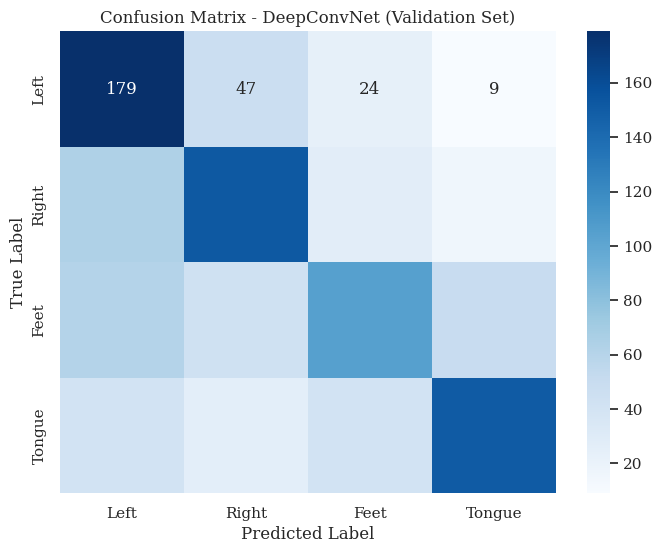

In [37]:


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['Left', 'Right', 'Feet', 'Tongue'],
    yticklabels=['Left', 'Right', 'Feet', 'Tongue']
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DeepConvNet (Validation Set)")
plt.savefig(os.path.join(plots_dir, f"{model_name}_confusion_matrix.png"))
plt.show()


In [ ]:
# Test all architectures
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Basic EEG Transformer
model1 = EEGTransformer(num_classes=4, channels=22, samples=1001).to(device)

# Multi-scale version
model2 = MultiScaleEEGTransformer(num_classes=4, channels=22, samples=1001).to(device)

# Vision Transformer style
model3 = EEGViT(num_classes=4, channels=22, samples=1001).to(device)

# Test with your data
for model_name, model in [("EEGTransformer", model1),
                         ("MultiScale", model2),
                         ("EEGViT", model3)]:
    # Test forward pass
    test_input = torch.randn(4, 1, 22, 1001).to(device)
    output = model(test_input)
    print(f"{model_name}: Input {test_input.shape} -> Output {output.shape}")

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name} parameters: {total_params:,}")
    print()

EEGTransformer: Input torch.Size([4, 1, 22, 1001]) -> Output torch.Size([4, 4])
EEGTransformer parameters: 3,634,564

MultiScale: Input torch.Size([4, 1, 22, 1001]) -> Output torch.Size([4, 4])
MultiScale parameters: 7,426,564

EEGViT: Input torch.Size([4, 1, 22, 1001]) -> Output torch.Size([4, 4])
EEGViT parameters: 9,493,252



In [ ]:
import torch.optim as optim

def train_transformer(model, model_name, train_loader, val_loader, device, epochs=200):
    """Train transformer model and return results"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)  # Lower LR for transformers

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0
    results = []

    print(f"\n=== Training {model_name} ===")

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()

            # Gradient clipping for transformers
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == batch_y).sum().item()
            train_total += batch_y.size(0)

        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == batch_y).sum().item()
                val_total += batch_y.size(0)

        val_acc = val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)

        # Update learning rate
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name.lower()}_model.pth')

        # Store results
        results.append({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'train_acc': train_acc,
            'val_loss': avg_val_loss,
            'val_acc': val_acc,
            'lr': current_lr
        })

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch [{epoch+1}/{epochs}] - "
                  f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} - "
                  f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f} - "
                  f"LR: {current_lr:.7f}")

    print(f"{model_name} Best Validation Accuracy: {best_val_acc:.4f}")
    return results, best_val_acc

# Train all transformer models
transformer_results = {}

# Make sure you have train_loader and val_loader from your MOABB data
models_to_test = [
    ("EEGTransformer", EEGTransformer(num_classes=4, channels=22, samples=1001).to(device)),
    ("MultiScale", MultiScaleEEGTransformer(num_classes=4, channels=22, samples=1001).to(device)),
    ("EEGViT", EEGViT(num_classes=4, channels=22, samples=1001).to(device))
]

for model_name, model in models_to_test:
    results, best_acc = train_transformer(
        model, model_name, train_loader, val_loader, device, epochs=400
    )
    transformer_results[model_name] = {
        'results': results,
        'best_acc': best_acc,
        'params': sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

# Compare results
print("\n" + "="*60)
print("TRANSFORMER COMPARISON RESULTS")
print("="*60)

for model_name, data in transformer_results.items():
    print(f"{model_name:15} | Best Val Acc: {data['best_acc']:.4f} | Parameters: {data['params']:,}")

print("\nFor comparison with your previous models:")
print("- Random chance: ~25%")
print("- Your CNN/DeepConvNet: ~25% (not learning)")
print("- Supervisor's CNN: ~90% (but 2 classes)")


=== Training EEGTransformer ===
Epoch [1/400] - Train Loss: 1.4739, Train Acc: 0.1935 - Val Loss: 1.4052, Val Acc: 0.2586 - LR: 0.0001000
Epoch [6/400] - Train Loss: 1.3810, Train Acc: 0.3283 - Val Loss: 1.4102, Val Acc: 0.3190 - LR: 0.0000999
Epoch [11/400] - Train Loss: 1.1729, Train Acc: 0.4783 - Val Loss: 1.5062, Val Acc: 0.2672 - LR: 0.0000998
Epoch [16/400] - Train Loss: 0.9002, Train Acc: 0.6196 - Val Loss: 1.7598, Val Acc: 0.3534 - LR: 0.0000996
Epoch [21/400] - Train Loss: 0.6832, Train Acc: 0.7043 - Val Loss: 2.2957, Val Acc: 0.3190 - LR: 0.0000993
Epoch [26/400] - Train Loss: 0.3616, Train Acc: 0.8522 - Val Loss: 2.6173, Val Acc: 0.3707 - LR: 0.0000990
Epoch [31/400] - Train Loss: 0.4523, Train Acc: 0.8196 - Val Loss: 2.5859, Val Acc: 0.2931 - LR: 0.0000985
Epoch [36/400] - Train Loss: 0.1828, Train Acc: 0.9457 - Val Loss: 3.1116, Val Acc: 0.2931 - LR: 0.0000980
Epoch [41/400] - Train Loss: 0.2109, Train Acc: 0.9130 - Val Loss: 3.2688, Val Acc: 0.2672 - LR: 0.0000974
Epoch 

In [16]:
%%writefile models/deepconvnet.py

import torch
import torch.nn as nn

class DeepConvNet(nn.Module):
    def __init__(self, num_classes=4, channels=22, samples=1001, dropout=0.5):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 25, kernel_size=(1, 5), padding=(0, 2))
        self.batchnorm1 = nn.BatchNorm2d(25)
        self.elu = nn.ELU()

        self.conv2 = nn.Conv2d(25, 25, kernel_size=(channels, 1))
        self.batchnorm2 = nn.BatchNorm2d(25)
        self.pool = nn.MaxPool2d(kernel_size=(1, 2))
        self.dropout_layer = nn.Dropout(dropout)

        self.conv3 = nn.Conv2d(25, 50, kernel_size=(1, 5), padding=(0, 2))
        self.batchnorm3 = nn.BatchNorm2d(50)

        self.globalpool = nn.AdaptiveAvgPool2d((1, 1))

        self.features = nn.Sequential(
            self.conv1,
            self.batchnorm1,
            self.conv2,
            self.batchnorm2,
            self.elu,
            self.pool,
            self.dropout_layer,
            self.conv3,
            self.batchnorm3,
            self.elu,
            self.pool,
            self.dropout_layer
        )

        # self.classify = nn.Linear(50, num_classes)

        self.classify = nn.Linear(50 , num_classes)


    def forward(self, x):
        x = self.features(x)
        x = self.globalpool(x)
        x = x.view(x.size(0), -1)
        return self.classify(x)


Overwriting models/deepconvnet.py


In [17]:
import importlib
import models.deepconvnet
importlib.reload(models.deepconvnet)

from models.deepconvnet import DeepConvNet


In [33]:

import torch
import torch.nn as nn

class DeepConvNet(nn.Module):
    def __init__(self, num_classes=4, channels=22, samples=1001, dropout=0.5):
        super(DeepConvNet, self).__init__()

        self.conv1 = nn.Conv2d(1, 25, (1, 5), padding=(0, 2))
        self.batchnorm1 = nn.BatchNorm2d(25)

        self.conv2 = nn.Conv2d(25, 25, (channels, 1))
        self.batchnorm2 = nn.BatchNorm2d(25)
        self.elu = nn.ELU()
        self.pool = nn.MaxPool2d(kernel_size=(1, 2))
        self.dropout = nn.Dropout(dropout)

        self.conv3 = nn.Conv2d(25, 50, (1, 5), padding=(0, 2))
        self.batchnorm3 = nn.BatchNorm2d(50)


        self.classify = nn.Linear(50 * int(samples/4), num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.conv2(x)
        x = self.batchnorm2(x)
        x = self.elu(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = self.conv3(x)
        x = self.batchnorm3(x)
        x = self.elu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = x.view(x.size(0), -1)
        return self.classify(x)


TypeError: super(type, obj): obj must be an instance or subtype of type

In [144]:
!git push origin main

Enumerating objects: 50, done.
Counting objects: 100% (46/46), done.
Delta compression using up to 2 threads
Compressing objects: 100% (39/39), done.
Writing objects: 100% (40/40), 145.92 KiB | 9.73 MiB/s, done.
Total 40 (delta 25), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (25/25), completed with 5 local objects.
To https://github.com/VictoryChianumba/robust-eeg-models.git
   eeb49b2..4e2f159  main -> main


In [105]:
os.getcwd()

'/content/robust-eeg-models'

In [106]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python311.zip',
 '/usr/lib/python3.11',
 '/usr/lib/python3.11/lib-dynload',
 '',
 '/usr/local/lib/python3.11/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.11/dist-packages/IPython/extensions',
 '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor',
 '/root/.ipython',
 '/tmp/tmp7yx2ntj4']

In [108]:
import os

file_path = os.path.join(os.getcwd(), 'training', 'run_optimization.py')

try:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        if len(lines) >= 9:
            print(f"Content of {file_path} (Line 9):")
            print(lines[8]) # Line 9 is index 8
        else:
            print(f"File {file_path} has less than 9 lines.")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Content of /content/robust-eeg-models/training/run_optimization.py (Line 9):
def run_optimization(X, y, model_type='EEGNet', n_trials=50, save_every=5):



In [1]:
!pip install pandas